# 🛍️ Merch Sales Analysis Project

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np 
import scipy as stats

# Load dataset
dfa = pd.read_csv('merch_sales.csv')

# Convert Order Date to datetime
dfa['Order Date'] = pd.to_datetime(dfa['Order Date'])
dfa.head()


,Order ID,Order Date,Product ID,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Review
0,189440,2024-07-21,BF1543,Clothing,Male,30,New Jersey,No,100,0,100,1,100,4,The delivery team handled the product with care.
1,187385,2024-07-20,BF1543,Clothing,Male,32,Las Vegas,No,100,0,100,1,100,3,Had slight delays but the product was in good ...
2,181844,2024-07-21,BF1544,Other,Female,26,Cardiff,Yes,9,40,49,1,49,2,Waste of Money.
3,197934,2024-08-19,BF1544,Other,Male,28,Pittsburgh,No,9,0,9,2,18,3,Had slight delays but the product was in good ...
4,122470,2024-01-06,BF1545,Other,Female,19,Miami,No,10,0,10,3,30,5,Lack of delivery delays is greatly appreciated.


## 🔎 Step 2: Basic Data Overview

In [2]:
print('Shape:', dfa.shape)
print(dfa.info())
dfa.describe()
dfa.isnull().sum()

Shape: (7394, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7394 entries, 0 to 7393
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order ID                7394 non-null   int64         
 1   Order Date              7394 non-null   datetime64[ns]
 2   Product ID              7394 non-null   object        
 3   Product Category        7394 non-null   object        
 4   Buyer Gender            7394 non-null   object        
 5   Buyer Age               7394 non-null   int64         
 6   Order Location          7394 non-null   object        
 7   International Shipping  7394 non-null   object        
 8   Sales Price             7394 non-null   int64         
 9   Shipping Charges        7394 non-null   int64         
 10  Sales per Unit          7394 non-null   int64         
 11  Quantity                7394 non-null   int64         
 12  Total Sales             7394 n

Order ID                  0
Order Date                0
Product ID                0
Product Category          0
Buyer Gender              0
Buyer Age                 0
Order Location            0
International Shipping    0
Sales Price               0
Shipping Charges          0
Sales per Unit            0
Quantity                  0
Total Sales               0
Rating                    0
Review                    0
dtype: int64

## 📊 Step 3: Sales Analysis

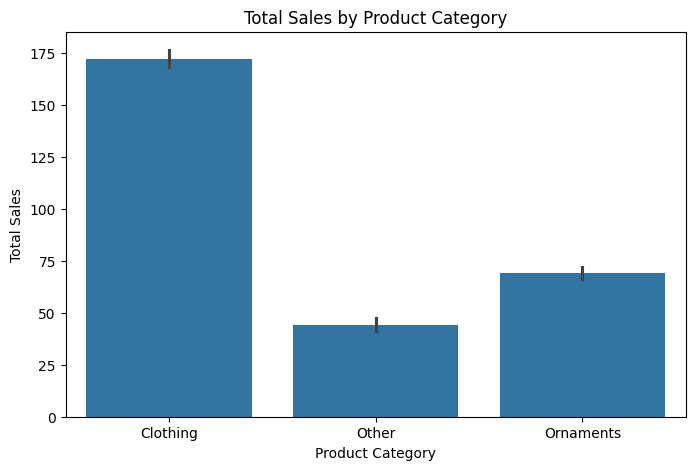

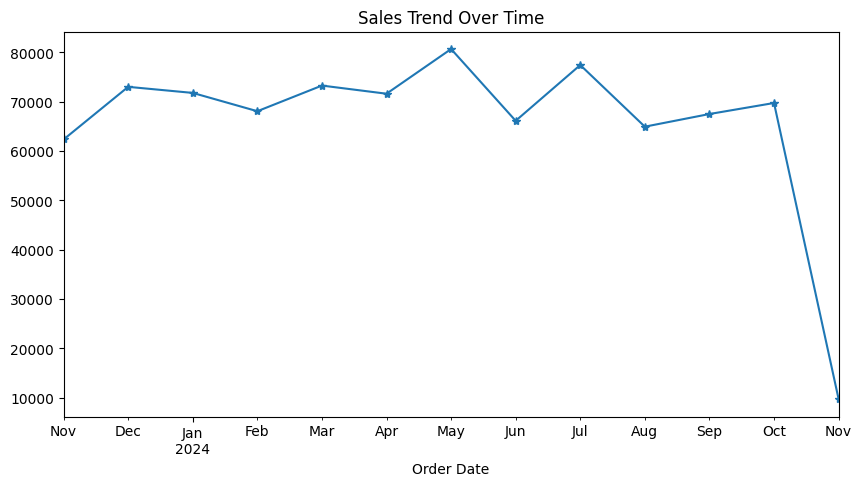

In [3]:
# Total Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(x='Product Category', y='Total Sales', data=dfa)
plt.title('Total Sales by Product Category')
plt.show()

# Sales Trend over Time
sales_trend = dfa.groupby(dfa['Order Date'].dt.to_period('M'))['Total Sales'].sum()
sales_trend.plot(kind='line', figsize=(10,5), marker='*', title='Sales Trend Over Time')
plt.show()

## 👥 Step 4: Customer Insights

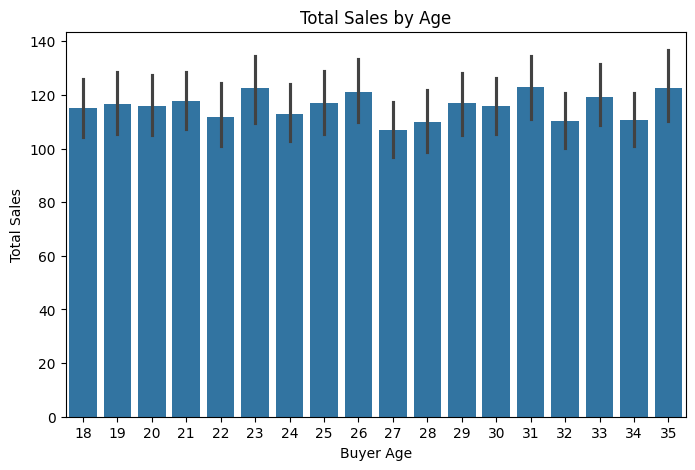

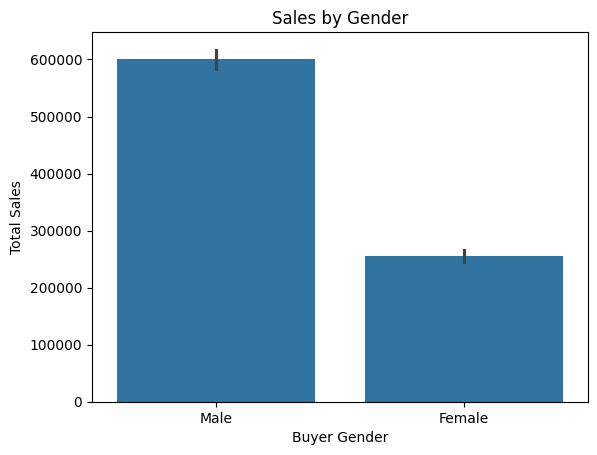

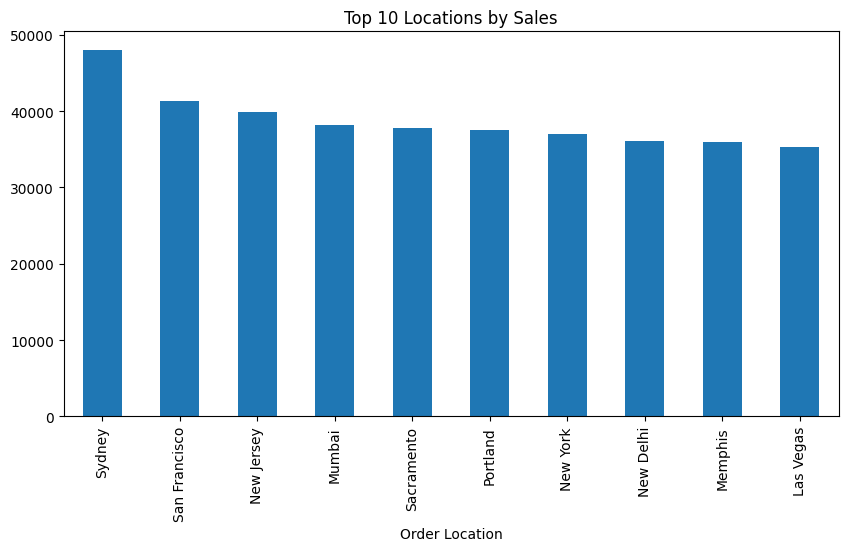

In [4]:
# Age vs Spending
plt.figure(figsize=(8,5))
sns.barplot(x='Buyer Age', y='Total Sales', data=dfa)
plt.title('Total Sales by Age')
plt.show()

# Gender vs Sales
sns.barplot(x='Buyer Gender', y='Total Sales', data=dfa, estimator=sum)
plt.title('Sales by Gender')
plt.show()             

# Top Locations
dfa.groupby('Order Location')['Total Sales'].sum().sort_values(ascending=False).head(10).plot(
    kind ='bar', figsize=(10,5), title='Top 10 Locations by Sales')
plt.show()

## 👥 Step 5: statistical analysis

In [5]:
# T - TEST , ANNOVA , TWO WAY ANNOVA

import numpy as np  
from scipy import stats  

# Population Mean 
mu = 100

# Sample Size
N1 = 21

# Degrees of freedom  
dof = N1 - 1

# Generate a random sample with mean = 11 and standard deviation = 1
x = np.random.randn(N1) + 11

# Using the Stats library, compute t-statistic and p-value
t_stat, p_val = stats.ttest_1samp(a=x, popmean = mu)
print("T-statistic = " + str(t_stat))
print("P-value = " + str(p_val))


# p-value is < 0.05 then we reject the null hypothesis

# if p-value greater then 0.05 then we accept the null hypothesis

dfa_full = pd.read_csv("./merch_sales.csv")
# the average rating for any product in my database is 3
pop_mean= dfa_full["Rating"].mean()

pop_size = len(dfa_full["Rating"])
sample_data = dfa_full["Rating"].iloc[3000:6000]
sample_size = len(sample_data)

sample_mean = sample_data.mean()

normal_distro = np.random.randn(sample_size) + sample_mean

t_test,p_val = stats.ttest_1samp(a=normal_distro,popmean=pop_mean)
print("t-statistic = " + str(t_stat))  
print("p-VALUE = " + str(p_val))


# ANNOVA :-

# Create sample data
data = {
    'Region': ['North', 'North', 'North',
               'South', 'South', 'South',
               'East', 'East', 'East'],
    'Sales': [250, 260, 245, 300, 310, 295, 270, 275, 265]
}

dfa = pd.DataFrame(data)

# # Separate data by group
north = dfa[dfa['Region'] == 'North']['Sales']
south = dfa[dfa['Region'] == 'South']['Sales']
east =  dfa[dfa['Region'] == 'East']['Sales']

# One-way ANOVA
f_stat, p_value = stats.f_oneway(north, south, east)
print("F-Statistic:", f_stat)
print("P-Value:", p_value)
print(f_stat, p_value)

# TWO WAY ANNOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols     

# Create sample data
data = {
    'Region': ['North', 'North', 'North', 'North',
                'South', 'South', 'South', 'South',
                'East', 'East', 'East', 'East'],
    'Product': ['A', 'A', 'B', 'B',
                'A', 'A', 'B', 'B',
                'A', 'A', 'B', 'B'],
    'Sales': [250, 260, 245, 255,
                300, 310, 295, 305,
                270, 275, 265, 280]
}                   
dfa = pd.DataFrame(data)

# Fit the two-way ANOVA model
model = ols('Sales ~ C(Region) + C(Product) + C(Region):C(Product)', data=dfa).fit()
anova_tab = sm.stats.anova_lm(model, typ=2)
print(anova_tab)

T-statistic = -396.0240700592289
P-value = 2.00142039913697e-40
t-statistic = -396.0240700592289
p-VALUE = 0.32006871127492464
F-Statistic: 40.64705882352939
P-Value: 0.0003247123542668164
40.64705882352939 0.0003247123542668164
                           sum_sq   df          F    PR(>F)
C(Region)             5066.666667  2.0  46.769231  0.000219
C(Product)              33.333333  1.0   0.615385  0.462605
C(Region):C(Product)    16.666667  2.0   0.153846  0.860681
Residual               325.000000  6.0        NaN       NaN


## 📦 Step 6: Product Insights

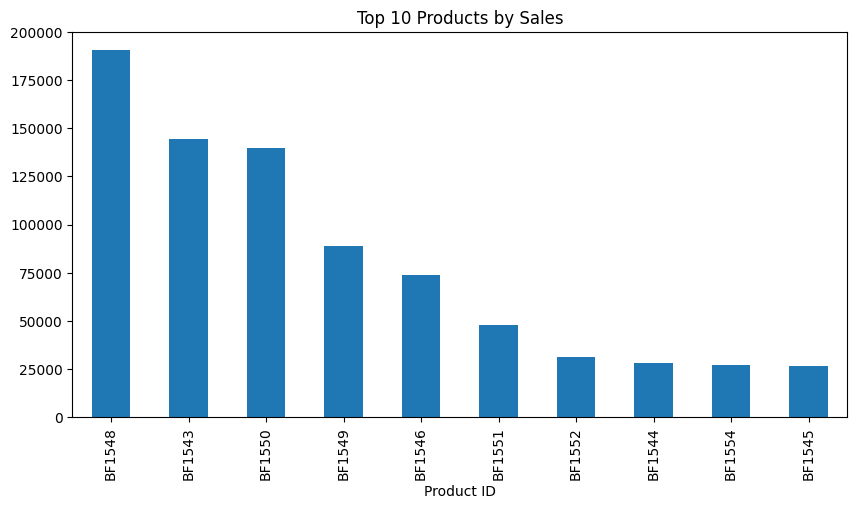

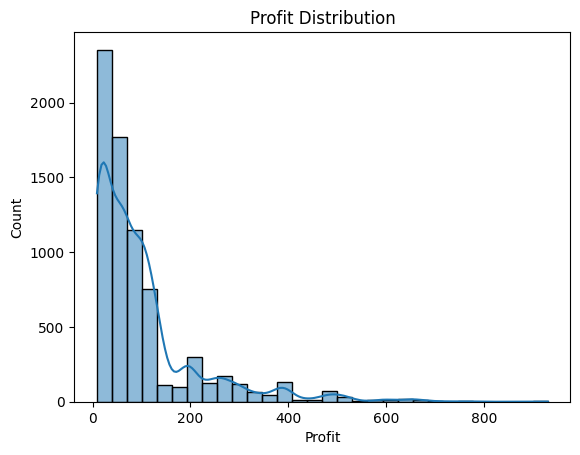

In [6]:
# Top 10 Products
dfa_full.groupby('Product ID')['Total Sales'].sum().sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(10,5), title='Top 10 Products by Sales')
plt.show()

# Profitability
dfa_full['Profit'] = dfa_full['Total Sales'] - dfa_full['Shipping Charges']
sns.histplot(dfa_full['Profit'], bins=30, kde=True)
plt.title('Profit Distribution')
plt.show()

## ⭐ Step 7: Ratings & Reviews

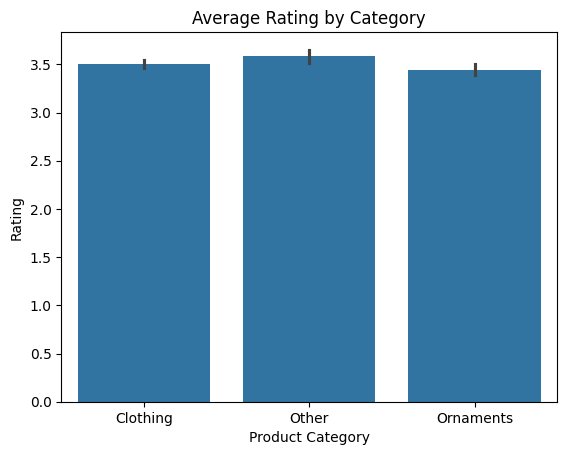

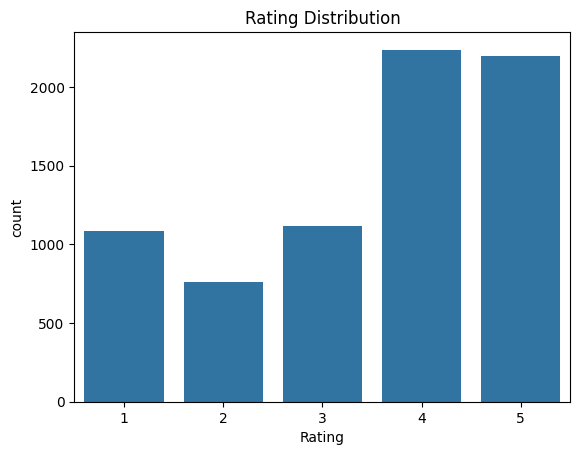

In [7]:
# Average Rating by Category
sns.barplot(x='Product Category', y='Rating', data=dfa_full, estimator=np.mean)
plt.title('Average Rating by Category')
plt.show()

# Rating Distribution
sns.countplot(x='Rating', data=dfa_full).set(title='Rating Distribution')
plt.show()
